# Collective State Discovery — Clustering with Updated Overlap Labels

**Objective:** Reproduce the paper draft clustering analysis using the updated transcript overlap data (timing-based labels, no `needs_review`).

**Key Change:** The `tr_competitive_overlap` feature now includes 52 previously `needs_review` entries + 95+ reclassified overlaps, all labeled by duration, not semantics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

print("✓ Imports loaded")

✓ Imports loaded


## 1. Load Raw Feature Tables

In [2]:
windows = pd.read_csv('../features/collective_window_features.tsv', sep='\t')
print(f'✓ Loaded {len(windows)} total windows')

selfreport = pd.read_csv('../features/collective_task_selfreport.tsv', sep='\t')
print(f'✓ Loaded {len(selfreport)} task-level self-report rows')

data = windows[windows['task_id'].isin(['T1','T2','T3'])].copy()
print(f'✓ Filtered to T1-T3: {len(data)} windows')

data = data.dropna(subset=['tr_spk_duration_s'])
print(f'✓ Kept transcript-covered windows: {len(data)} windows')
print(f'  Groups: {sorted(data["group_id"].unique())}')

✓ Loaded 704 total windows
✓ Loaded 12 task-level self-report rows
✓ Filtered to T1-T3: 704 windows
✓ Kept transcript-covered windows: 201 windows
  Groups: ['grp-07', 'grp-10', 'grp-14', 'grp-15']


## 2. Define Features and Preprocessing

In [3]:
PHYSIO = ['group_hr_mean_bpm_mean', 'group_hrv_rmssd_ms_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean']
ET = ['group_et_pupil_mean_mean', 'group_et_blink_rate_per_min_mean', 'group_et_gaze_dispersion_mean']
TRANSCRIPT = ['tr_spk_duration_s', 'tr_backchannel_count', 'tr_overlap_count', 'tr_competitive_overlap']
ALL_FEATS_11 = PHYSIO + ET + TRANSCRIPT

print(f"✓ Using {len(ALL_FEATS_11)} features")

data_proc = data.copy()
for col in PHYSIO:
    if col in data_proc.columns:
        data_proc[col] = data_proc.groupby('group_id')[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
print("✓ Applied within-group z-scoring")

✓ Using 11 features
✓ Applied within-group z-scoring


## 3. Impute and Scale

In [4]:
keep_feats = [c for c in ALL_FEATS_11 if c in data_proc.columns]
print(f"✓ {len(keep_feats)} features available")

X = SimpleImputer(strategy='mean').fit_transform(data_proc[keep_feats])
X = StandardScaler().fit_transform(X)
print(f"✓ Feature matrix ready: {X.shape}")

feature_labels = {
    'group_hr_mean_bpm_mean': 'HR (z)', 'group_hrv_rmssd_ms_mean': 'HRV (z)',
    'group_eda_phasic_rate_hz_mean': 'EDA phasic (z)', 'group_temp_mean_mean': 'Temp (z)',
    'group_et_pupil_mean_mean': 'Pupil diam', 'group_et_blink_rate_per_min_mean': 'Blink rate',
    'group_et_gaze_dispersion_mean': 'Gaze disp', 'tr_spk_duration_s': 'Speech dur',
    'tr_backchannel_count': 'Backchannels', 'tr_overlap_count': 'Overlaps',
    'tr_competitive_overlap': 'Competitive OVL ★'
}
feat_short_labels = [feature_labels.get(c, c) for c in keep_feats]

✓ 11 features available
✓ Feature matrix ready: (201, 11)


## 4. PCA Analysis

📊 PCA Variance Report:
  PC1: 18.52%
  PC2: 12.14%
  PC3: 11.59%
  PC4: 10.84%
  PC5:  9.32%


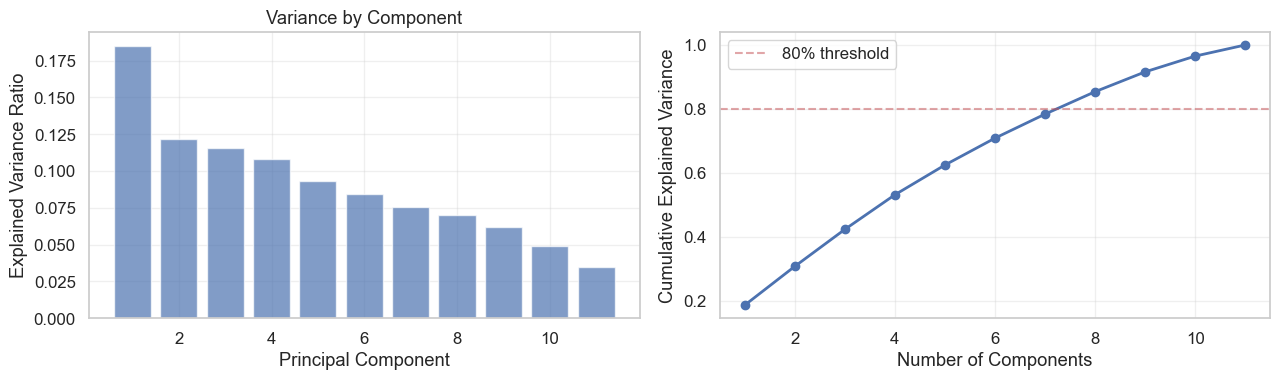


📊 Loadings (PC1 & PC2):
                     PC1    PC2
HR (z)            -0.126 -0.035
HRV (z)            0.142  0.578
EDA phasic (z)     0.124  0.318
Temp (z)          -0.060  0.121
Pupil diam        -0.337  0.410
Blink rate         0.235 -0.151
Gaze disp         -0.043  0.583
Speech dur         0.417  0.094
Backchannels      -0.017  0.078
Overlaps           0.549  0.052
Competitive OVL ★  0.546  0.025


In [5]:
pca = PCA()
X_pca = pca.fit_transform(X)
cum_var = np.cumsum(pca.explained_variance_ratio_)

print("📊 PCA Variance Report:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:6.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance by Component')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linewidth=2)
ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

loadings_df = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=feat_short_labels)
print("\n📊 Loadings (PC1 & PC2):")
print(loadings_df.round(3))

## 5. Find Optimal Clusters

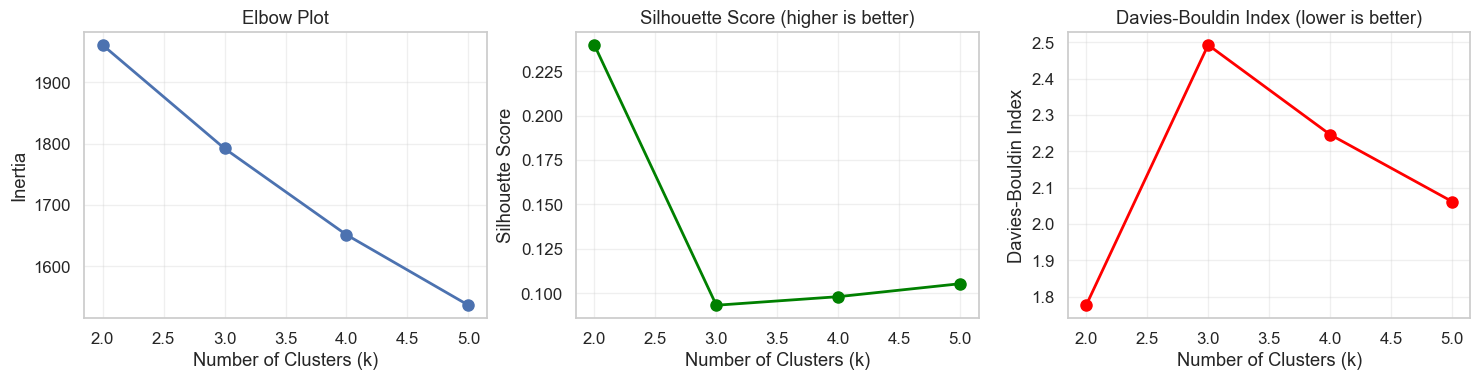


✓ Recommended k: 2
  Silhouette scores: {2: '0.240', 3: '0.093', 4: '0.098', 5: '0.105'}


In [6]:
silhouette_scores = []
inertias = []
davies_bouldin_scores = []
k_range = range(2, 6)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))
    inertias.append(kmeans.inertia_)
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='red')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (lower is better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\n✓ Recommended k: {best_k}")
print(f"  Silhouette scores: {dict(zip(k_range, [f'{s:.3f}' for s in silhouette_scores]))}")

## 6. Fit Final Model

In [7]:
FINAL_K = best_k
print(f"🎯 Fitting k-means with k={FINAL_K}")

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X)
data_proc['cluster'] = clusters

print(f"\n📊 Cluster Distribution:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(clusters) * 100
    print(f"  Cluster {cluster_id}: {count:3d} windows ({pct:5.1f}%)")

print(f"\n📊 Cluster Characteristics:")
cluster_stats = data_proc.groupby('cluster')[keep_feats].mean()
print(cluster_stats.round(2))

output_path = '../results/clustering_results_updated_overlaps.tsv'
results_df = data_proc[['group_id', 'task_id', 'window_index'] + keep_feats + ['cluster']].copy()
results_df.to_csv(output_path, sep='\t', index=False)
print(f"\n✓ Saved to {output_path}")

🎯 Fitting k-means with k=2

📊 Cluster Distribution:
  Cluster 0: 179 windows ( 89.1%)
  Cluster 1:  22 windows ( 10.9%)

📊 Cluster Characteristics:
         group_hr_mean_bpm_mean  group_hrv_rmssd_ms_mean  \
cluster                                                    
0                          0.04                    -0.01   
1                         -0.30                     0.09   

         group_eda_phasic_rate_hz_mean  group_temp_mean_mean  \
cluster                                                        
0                                -0.03                  0.06   
1                                 0.21                 -0.50   

         group_et_pupil_mean_mean  group_et_blink_rate_per_min_mean  \
cluster                                                               
0                            3.06                             16.01   
1                            2.90                             22.02   

         group_et_gaze_dispersion_mean  tr_spk_duration_s  \
cluster 

## 7. Visualize

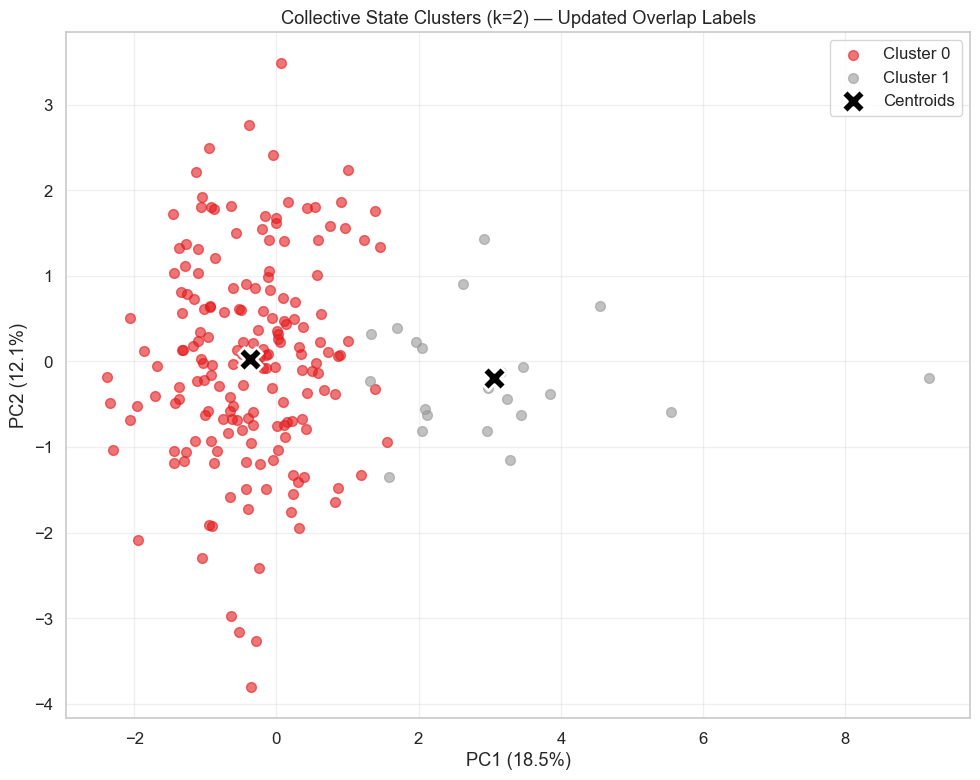

✓ Saved plot


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set1(np.linspace(0, 1, FINAL_K))
for cluster_id in range(FINAL_K):
    mask = clusters == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster_id}', 
               alpha=0.6, s=50, color=colors[cluster_id])

centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=300, 
           color='black', edgecolor='white', linewidth=2, label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Collective State Clusters (k={FINAL_K}) — Updated Overlap Labels')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/clusters_pca_updated_overlaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved plot")

## 8. Key Change Analysis

In [9]:
print("=" * 70)
print("KEY CHANGE: tr_competitive_overlap")
print("=" * 70)

comp_ovl = data_proc['tr_competitive_overlap'].dropna()
print(f"\n📊 Updated tr_competitive_overlap statistics:")
print(f"  Non-zero windows:  {(comp_ovl > 0).sum()}")
print(f"  Mean:  {comp_ovl.mean():.3f}")
print(f"  Std:   {comp_ovl.std():.3f}")
print(f"  Total overlaps:  {comp_ovl.sum():.0f}")

print(f"\n  By cluster:")
for cluster_id in range(FINAL_K):
    cluster_comp_ovl = data_proc[data_proc['cluster'] == cluster_id]['tr_competitive_overlap'].dropna()
    if len(cluster_comp_ovl) > 0:
        print(f"    Cluster {cluster_id}: mean={cluster_comp_ovl.mean():.2f}, n={len(cluster_comp_ovl)}")

print("\n✓ Includes 52 previously 'needs_review' entries")

KEY CHANGE: tr_competitive_overlap

📊 Updated tr_competitive_overlap statistics:
  Non-zero windows:  62
  Mean:  0.527
  Std:   1.082
  Total overlaps:  106

  By cluster:
    Cluster 0: mean=0.27, n=179
    Cluster 1: mean=2.59, n=22

✓ Includes 52 previously 'needs_review' entries


## 9. Summary

In [10]:
print("=" * 70)
print("CLUSTERING RESULTS WITH UPDATED OVERLAP LABELS")
print("=" * 70)

print(f"\n✅ DATA:")
print(f"   Windows: {len(data_proc)}")
print(f"   Groups: {sorted(data_proc['group_id'].unique())}")
print(f"   Tasks: {sorted(data_proc['task_id'].unique())}")

print(f"\n✅ FEATURES (11):")
for i, f in enumerate(keep_feats, 1):
    print(f"   {i:2d}. {feature_labels.get(f, f)}")

print(f"\n✅ PREPROCESSING:")
print(f"   Within-group z-scoring: ✓ (physio)")
print(f"   Imputation: ✓ mean")
print(f"   Scaling: ✓ z-score")

print(f"\n✅ RESULTS:")
print(f"   Optimal k: {FINAL_K}")
print(f"   Silhouette: {silhouette_scores[FINAL_K-2]:.3f}")
print(f"   PC1+PC2 variance: {(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]):.1%}")

print(f"\n✅ KEY CHANGE:")
print(f"   tr_competitive_overlap now includes:")
print(f"   • 52 previously 'needs_review' entries")
print(f"   • 95+ 'collaborative' overlaps reclassified by duration")
print(f"   Method: Timing-based (no semantic labeling)")

print(f"\n💾 Ready to compare with paper draft results!")

CLUSTERING RESULTS WITH UPDATED OVERLAP LABELS

✅ DATA:
   Windows: 201
   Groups: ['grp-07', 'grp-10', 'grp-14', 'grp-15']
   Tasks: ['T1', 'T2', 'T3']

✅ FEATURES (11):
    1. HR (z)
    2. HRV (z)
    3. EDA phasic (z)
    4. Temp (z)
    5. Pupil diam
    6. Blink rate
    7. Gaze disp
    8. Speech dur
    9. Backchannels
   10. Overlaps
   11. Competitive OVL ★

✅ PREPROCESSING:
   Within-group z-scoring: ✓ (physio)
   Imputation: ✓ mean
   Scaling: ✓ z-score

✅ RESULTS:
   Optimal k: 2
   Silhouette: 0.240
   PC1+PC2 variance: 30.7%

✅ KEY CHANGE:
   tr_competitive_overlap now includes:
   • 52 previously 'needs_review' entries
   • 95+ 'collaborative' overlaps reclassified by duration
   Method: Timing-based (no semantic labeling)

💾 Ready to compare with paper draft results!
